In [11]:
# نصب hazm
!pip install --no-deps hazm==0.10.0
!pip install fasttext-wheel==0.9.2 flashtext==2.7 gensim==4.3.3 python-crfsuite

In [12]:
# =========================
# سلول 1: تنظیمات اولیه و بارگذاری کتابخانه‌ها
# =========================
import warnings, os, random, logging, re
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# NLP
from hazm import Normalizer, word_tokenize, stopwords_list

# Vectorizers & Dimensionality Reduction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

# Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Anomaly detection models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.svm import OneClassSVM

# Supervised classifiers (برای آینده یا بررسی)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix, roc_curve)

# TensorFlow Autoencoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Plot settings
%matplotlib inline
sns.set(style="whitegrid")

# reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")
logger = logging.getLogger("__colab_anom__")

# اتصال به گوگل درایو و مسیر داده‌ها
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/digikala_project/digikala_data/merged_digikala.csv"
OUTPUT_DIR = "/content/drive/MyDrive/digikala_project/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# پیکربندی نمونه‌برداری و ویژگی‌ها
USE_SAMPLE = True
SAMPLE_N = 120_000  # تعداد نمونه‌ها
CHUNK_SIZE = 200_000

TFIDF_MAX_FEATURES = 2000
SVD_COMPONENTS = 50
KNN_K = 5
CONTAMINATION = 0.01
TOP_K = 200
EVAL_KS = [50, 100, 200, 500, 1000]

logger.info("CONFIG: DATA_PATH=%s, OUTPUT_DIR=%s, SAMPLE_N=%s", DATA_PATH, OUTPUT_DIR, SAMPLE_N)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# =========================
# سلول 2: خواندن و نمونه‌برداری داده‌ها
# =========================
def stream_sample_dataframe(data_path, chunksize=CHUNK_SIZE, sample_n=None):
    sampled_parts = []
    total_taken = 0
    reader = pd.read_csv(data_path, chunksize=chunksize)
    for chunk in tqdm(reader, desc="Reading chunks"):
        needed_cols = [c for c in ["body","rate","likes","dislikes","created_at","is_buyer","product_id"] if c in chunk.columns]
        chunk = chunk[needed_cols].copy()
        if "body" not in chunk.columns:
            continue
        chunk = chunk.loc[chunk["body"].notnull() & (chunk["body"].str.strip() != "")].copy()
        if chunk.shape[0] == 0:
            continue
        remaining = sample_n - total_taken
        if remaining <= 0: break
        part = chunk.sample(n=min(remaining, chunk.shape[0]), random_state=RANDOM_SEED)
        sampled_parts.append(part)
        total_taken += part.shape[0]
        if total_taken >= sample_n: break
    if len(sampled_parts) == 0:
        raise ValueError("No data sampled. Check DATA_PATH.")
    df_sampled = pd.concat(sampled_parts, ignore_index=True)
    return df_sampled

if USE_SAMPLE:
    logger.info("Sampling up to %d rows...", SAMPLE_N)
    df_raw = stream_sample_dataframe(DATA_PATH, sample_n=SAMPLE_N)
else:
    logger.info("Reading entire dataset...")
    df_raw = pd.read_csv(DATA_PATH)

logger.info("Data shape: %s", df_raw.shape)
display(df_raw.head(5))


Reading chunks: 0it [00:02, ?it/s]


,body,rate,likes,dislikes,created_at,is_buyer,product_id
0,خیلی خیلی خیلی ارزانتر از بازار حتما از دیجی ک...,0.0,0,0,20 اسفند 1400,True,4296529
1,براي پوست هاي حساس و قرمز عاليه و بافت بسيار س...,5.0,0,0,11 آذر 1401,True,5113895
2,خیلی خوب و مناسب,4.0,0,0,30 خرداد 1402,True,883551
3,وضوح و کیفیت طرح ها عالی هستش,5.0,0,0,17 مرداد 1402,True,5377201
4,کاربری آسان،ارزش خرید نسبت به قیمت و با کیفیت ...,0.0,0,0,29 شهریور 1401,True,3913860


,clean_body,char_len,word_count,unique_word_ratio,emoji_count
0,خیلی خیلی خیلی ارزانتر از بازار حتما از دیجی ک...,55,11,0.727273,0
1,برای پوست های حساس و قرمز عالیه و بافت بسیار س...,72,15,0.866667,0
2,خیلی خوب و مناسب,16,4,1.000000,0
3,وضوح و کیفیت طرح ها عالی هستش,29,7,1.000000,0
4,کاربری آسان ارزش خرید نسبت به قیمت و با کیفیت ...,70,15,1.000000,0
5,وای بدش عالیه و خوبه,20,5,1.000000,0
6,معمولی,6,1,1.000000,0
7,رایحه بدی نداشت,15,3,1.000000,0
8,ممنون بابت ارسال عالی,21,4,1.000000,0
9,پیشنهاد می کنم حتما بخرید پشیمون نمیشید,39,7,1.000000,0


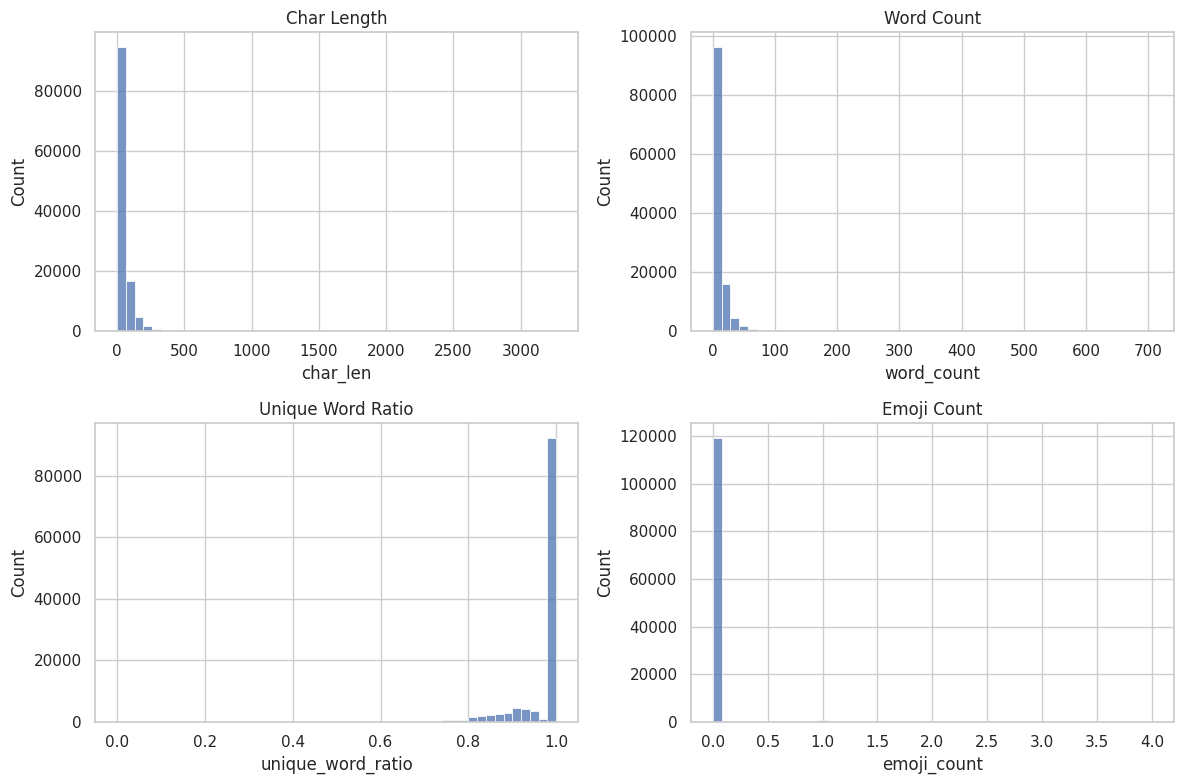

In [14]:
# =========================
# سلول 3: پیش‌پردازش متن و استخراج ویژگی‌ها
# =========================
normalizer = Normalizer()
stopwords = set(stopwords_list())

def clean_text(text):
    if not isinstance(text, str): return ""
    text = normalizer.normalize(text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"[^آ-یA-Za-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_remove_stopwords(text):
    toks = word_tokenize(text)
    toks = [t for t in toks if (t not in stopwords) and len(t) > 1]
    return toks

emoji_re = re.compile("["
                      u"\U0001F600-\U0001F64F"
                      u"\U0001F300-\U0001F5FF"
                      u"\U0001F680-\U0001F6FF"
                      u"\U0001F1E0-\U0001F1FF"
                      "]+", flags=re.UNICODE)
def emoji_count(text):
    if not isinstance(text, str): return 0
    return len(emoji_re.findall(text))

logger.info("Cleaning text and extracting basic features...")
df_raw["clean_body"] = df_raw["body"].map(clean_text)
df_raw["word_count"] = df_raw["clean_body"].map(lambda x: len(x.split()))
df_raw["char_len"] = df_raw["clean_body"].map(len)
df_raw["unique_word_ratio"] = df_raw["clean_body"].map(lambda x: len(set(x.split())) / max(1,len(x.split())))
df_raw["emoji_count"] = df_raw["body"].map(emoji_count)

if "created_at" in df_raw.columns:
    try:
        df_raw["created_at"] = pd.to_datetime(df_raw["created_at"], errors="coerce")
        df_raw["hour"] = df_raw["created_at"].dt.hour.fillna(-1).astype(int)
        df_raw["dayofweek"] = df_raw["created_at"].dt.dayofweek.fillna(-1).astype(int)
    except Exception as e:
        logger.warning("created_at parse failed: %s", e)

display(df_raw[["clean_body","char_len","word_count","unique_word_ratio","emoji_count"]].head(10))

# نمودار توزیع ویژگی‌ها
fig, axes = plt.subplots(2,2, figsize=(12,8))
sns.histplot(df_raw['char_len'], bins=50, ax=axes[0,0]).set(title="Char Length")
sns.histplot(df_raw['word_count'], bins=50, ax=axes[0,1]).set(title="Word Count")
sns.histplot(df_raw['unique_word_ratio'], bins=50, ax=axes[1,0]).set(title="Unique Word Ratio")
sns.histplot(df_raw['emoji_count'], bins=50, ax=axes[1,1]).set(title="Emoji Count")
plt.tight_layout(); plt.show()


In [15]:
# =========================
# سلول 4: ساخت بردار ویژگی‌ها و کاهش بعد
# =========================
logger.info("TF-IDF -> SVD feature construction...")
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1,2))
X_tfidf_sparse = tfidf.fit_transform(df_raw["clean_body"])
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_SEED)
X_tfidf_dense = svd.fit_transform(X_tfidf_sparse)
logger.info("TF-IDF -> SVD shape: %s", X_tfidf_dense.shape)

# ویژگی‌های عددی
numeric_cols = ["char_len","word_count","unique_word_ratio","emoji_count"]
for c in ["rate","likes","dislikes"]:
    if c in df_raw.columns: numeric_cols.append(c)
X_num = df_raw[numeric_cols].fillna(0).values
X_num_scaled = StandardScaler().fit_transform(X_num)

# ترکیب ویژگی‌ها
X_features = np.hstack([X_tfidf_dense, X_num_scaled])
X_scaled = StandardScaler().fit_transform(X_features)
logger.info("Final feature matrix shape: %s", X_scaled.shape)


In [16]:
# =========================
# سلول 5: اجرای مدل‌های ناهنجاری پایه
# =========================
logger.info("Fitting unsupervised anomaly models...")
results = pd.DataFrame(index=df_raw.index)

# Isolation Forest
iso = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_SEED)
results["iso_score"] = -iso.fit_predict(X_scaled) * iso.decision_function(X_scaled)

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=KNN_K, contamination=CONTAMINATION, novelty=True)
lof.fit(X_scaled)
results["lof_score"] = -lof.decision_function(X_scaled)

# KNN Distance (average distance to k neighbors)
nn = NearestNeighbors(n_neighbors=KNN_K+1).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
results["knn_dist"] = distances[:,1:].mean(axis=1)

# Ensemble (MinMax + mean)
scaler_mm = MinMaxScaler()
to_norm = scaler_mm.fit_transform(results[["iso_score","lof_score","knn_dist"]])
results["ensemble_score"] = to_norm.mean(axis=1)

df_out = pd.concat([df_raw.reset_index(drop=True), results.reset_index(drop=True)], axis=1)


--- iso_score ---


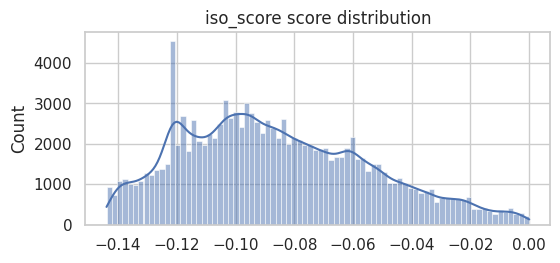

,body,clean_body,score
0,خيلي بسته بندي خوبي داشت و كتاب هم محتواي خوبي...,خیلی بسته بندی خوبی داشت و کتاب هم محتوای خوبی...,-3.173849e-07
1,خوشبو و قیمت مناسب,خوشبو و قیمت مناسب,-2.639992e-05
2,قیمت مناسب و خوشبو,قیمت مناسب و خوشبو,-2.639992e-05
3,قیمت مناسب و خوشبو,قیمت مناسب و خوشبو,-2.639992e-05
4,خوشبو و قیمت مناسب,خوشبو و قیمت مناسب,-2.639992e-05
5,در کل خوب است,در کل خوب است,-3.018942e-05


--- lof_score ---


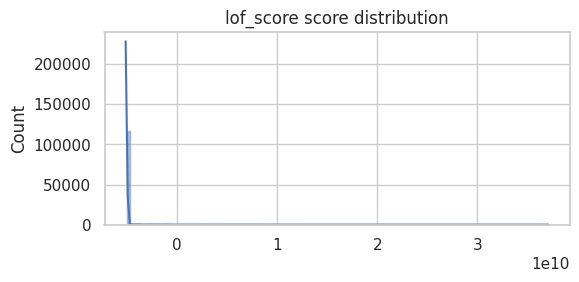

,body,clean_body,score
0,عالیه واقعا عالیه,عالیه واقعا عالیه,3.708714e+10
1,واقعا فوق العاده بود,واقعا فوق العاده بود,3.438539e+10
2,فوق العاده عالی بود,فوق العاده عالی بود,3.297179e+10
3,کتاب خوبیه قیمتش خیلی خوب بود,کتاب خوبیه قیمتش خیلی خوب بود,3.161488e+10
4,کتاب عالی توصیه میکنم تخفیفشم عالی بود,کتاب عالی توصیه می کنم تخفیفشم عالی بود,3.097371e+10
5,سلام توصیه میه نسبت یه قیمت,سلام توصیه می ه نسبت یه قیمت,3.044240e+10


--- knn_dist ---


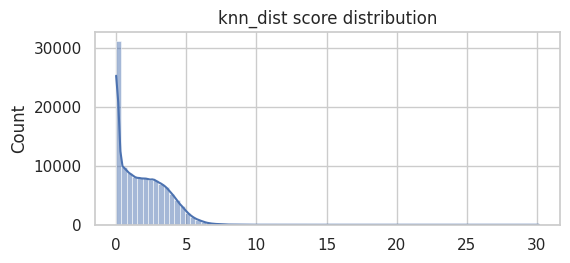

,body,clean_body,score
0,این محصول اولین اینکه پلمپ نیست\r\nبعدم اینکه ...,این محصول اولین اینکه پلمپ نیست بعدم اینکه بزن...,30.136125
1,با سلام اول از همه چند تا نکته میگم امیدوارم ت...,با سلام اول از همه چند تا نکته میگم امیدوارم ت...,23.915644
2,واقعا خیلی خوبه من روی لاک بنفش که زدم خیلی قش...,واقعا خیلی خوبه من روی لاک بنفش که زدم خیلی قش...,19.946122
3,خیللییییییی عاااالییییه \r\nتیکه داستان های شه...,خیللیی عالیه تیکه داستان های شهید حاج قاسم سلی...,19.701493
4,کیفیتش و سایزش خوبه ولی یجوریه انگار با گواش ر...,کیفیتش و سایزش خوبه ولی یجوریه انگار با گواش ر...,19.433441
5,دیجی کالا این رنگ رو مشکی میبینه,دیجی کالا این رنگ رو مشکی میبینه,17.653080


--- ensemble_score ---


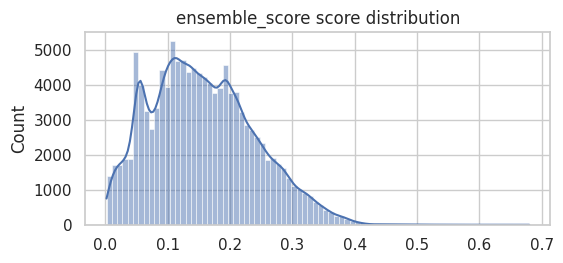

,body,clean_body,score
0,فوق العاده عالی بود,فوق العاده عالی بود,0.680166
1,واقعا فوق العاده بود,واقعا فوق العاده بود,0.669220
2,کتاب خوبیه قیمتش خیلی خوب بود,کتاب خوبیه قیمتش خیلی خوب بود,0.642797
3,این محصول اولین اینکه پلمپ نیست\r\nبعدم اینکه ...,این محصول اولین اینکه پلمپ نیست بعدم اینکه بزن...,0.601671
4,بسیار خوشبو و با کیفیت,بسیار خوشبو و با کیفیت,0.599030
5,این کتاب عالیه توسعه میکنم,این کتاب عالیه توسعه می کنم,0.594332


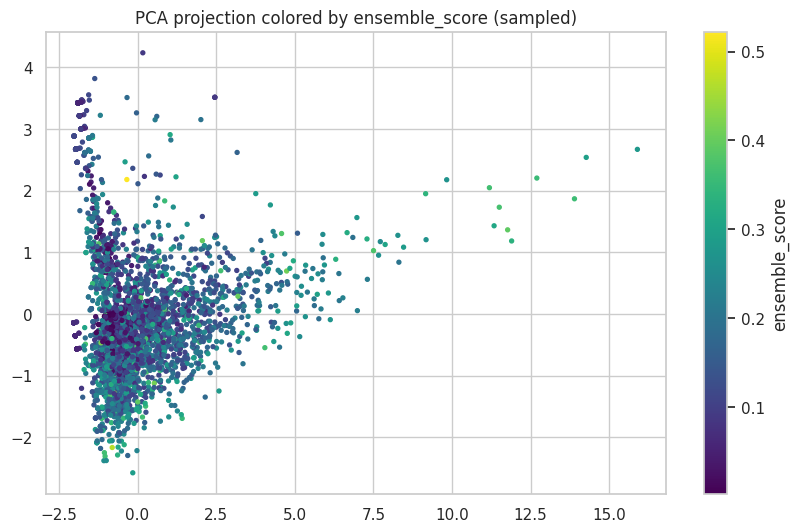

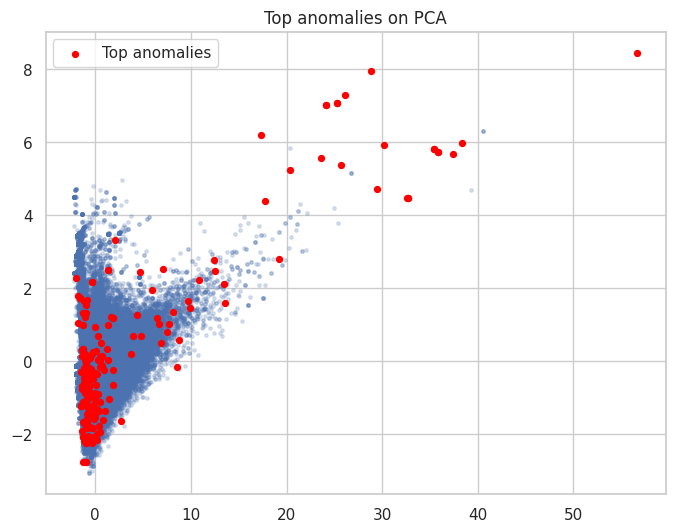

In [17]:
# =========================
# سلول 6: مصورسازی و نمایش top anomalies مدل‌های پایه
# =========================
def show_hist(scores, name):
    plt.figure(figsize=(6,2.5))
    sns.histplot(scores, bins=80, kde=True)
    plt.title(f"{name} score distribution")
    plt.show()

def show_top_texts(scores, df=df_out, topk=8):
    top_idx = np.argsort(-scores)[:topk]
    display(df.iloc[top_idx][['body','clean_body']].assign(score=scores[top_idx]).reset_index(drop=True))

for col in ["iso_score","lof_score","knn_dist","ensemble_score"]:
    print(f"--- {col} ---")
    show_hist(df_out[col].values, col)
    show_top_texts(df_out[col].values, topk=6)

# PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
df_vis = pd.DataFrame({"pca1": X_pca[:,0], "pca2": X_pca[:,1], "ensemble_score": df_out["ensemble_score"]})
sample_vis = df_vis.sample(n=min(3000, len(df_vis)), random_state=RANDOM_SEED)
plt.figure(figsize=(10,6))
plt.scatter(sample_vis["pca1"], sample_vis["pca2"], c=sample_vis["ensemble_score"], s=8, cmap="viridis")
plt.colorbar(label="ensemble_score")
plt.title("PCA projection colored by ensemble_score (sampled)")
plt.show()

# نمایش top anomalies
top_idx = df_out.sort_values("ensemble_score", ascending=False).head(TOP_K).index
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=6, alpha=0.2)
plt.scatter(X_pca[top_idx,0], X_pca[top_idx,1], c="red", s=18, label="Top anomalies")
plt.legend()
plt.title("Top anomalies on PCA")
plt.show()


,threshold,outliers_detected,normals_detected,outlier_ratio_%
model,,,,
LOF,-5.161121e+09,6001,113999,5.000833
Isolation,-2.609222e-02,6000,114000,5.000000
KNN,4.837440e+00,6000,114000,5.000000
Ensemble,3.058138e-01,6000,114000,5.000000



درصد همپوشانی ناهنجارها بین مدل‌ها:


,Isolation,LOF,KNN,Ensemble
Isolation,100.000000,10.416667,22.883333,71.950000
LOF,10.414931,100.000000,4.582570,13.864356
KNN,22.883333,4.583333,100.000000,39.550000
Ensemble,71.950000,13.866667,39.550000,100.000000


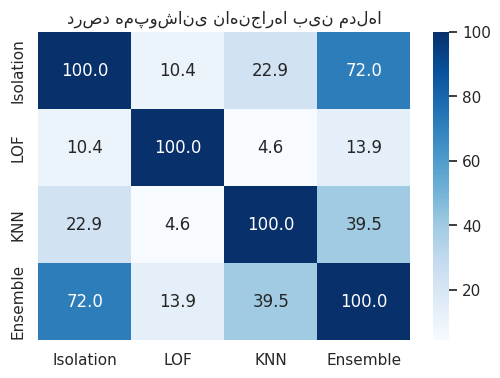

In [18]:
# =========================
# سلول 7: مقایسه مدل‌های ناهنجاری و همپوشانی
# =========================
method_scores = {
    "Isolation": df_out["iso_score"].values,
    "LOF": df_out["lof_score"].values,
    "KNN": df_out["knn_dist"].values,
    "Ensemble": df_out["ensemble_score"].values
}
threshold_percentile = 95

summary_rows = []
outlier_sets = {}
for name, scores in method_scores.items():
    threshold = np.nanpercentile(scores, threshold_percentile)
    y_pred = (scores >= threshold).astype(int)
    outlier_sets[name] = set(np.where(y_pred==1)[0])
    summary_rows.append({
        "model": name,
        "threshold": threshold,
        "outliers_detected": y_pred.sum(),
        "normals_detected": len(y_pred)-y_pred.sum(),
        "outlier_ratio_%": 100*y_pred.sum()/len(y_pred)
    })

summary_df = pd.DataFrame(summary_rows).set_index("model").sort_values("outliers_detected", ascending=False)
display(summary_df)

# همپوشانی
overlap_matrix = pd.DataFrame(index=method_scores.keys(), columns=method_scores.keys(), dtype=float)
for m1 in method_scores.keys():
    for m2 in method_scores.keys():
        overlap = len(outlier_sets[m1] & outlier_sets[m2])
        overlap_matrix.loc[m1,m2] = 100*overlap/len(outlier_sets[m1]) if len(outlier_sets[m1])>0 else 0
print("\nدرصد همپوشانی ناهنجارها بین مدل‌ها:")
display(overlap_matrix)

plt.figure(figsize=(6,4))
sns.heatmap(overlap_matrix.astype(float), annot=True, fmt=".1f", cmap="Blues")
plt.title("درصد همپوشانی ناهنجارها بین مدل‌ها")
plt.show()


In [19]:
# =========================
# سلول 8: اجرای One-Class SVM
# =========================
print("\n🚀 اجرای مدل جدید: One-Class SVM ...")
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAMINATION)
ocsvm.fit(X_scaled)
svm_scores = -ocsvm.decision_function(X_scaled)
df_out["ocsvm_score"] = svm_scores
method_scores["OneClassSVM"] = svm_scores

summary_rows2 = []
for name, scores in method_scores.items():
    threshold = np.nanpercentile(scores, threshold_percentile)
    y_pred = (scores >= threshold).astype(int)
    summary_rows2.append({
        "model": name,
        "threshold": threshold,
        "outliers_detected": y_pred.sum(),
        "normals_detected": len(y_pred)-y_pred.sum(),
        "outlier_ratio_%": 100*y_pred.sum()/len(y_pred)
    })
summary_df2 = pd.DataFrame(summary_rows2).set_index("model").sort_values("outliers_detected", ascending=False)
display(summary_df2)



🚀 اجرای مدل جدید: One-Class SVM ...


,threshold,outliers_detected,normals_detected,outlier_ratio_%
model,,,,
OneClassSVM,-1.273191e+00,6028,113972,5.023333
LOF,-5.161121e+09,6001,113999,5.000833
Isolation,-2.609222e-02,6000,114000,5.000000
KNN,4.837440e+00,6000,114000,5.000000
Ensemble,3.058138e-01,6000,114000,5.000000


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7211 - val_loss: 0.2435
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2095 - val_loss: 0.1443
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1343 - val_loss: 0.1115
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1060 - val_loss: 0.0925
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0896 - val_loss: 0.0808
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0778 - val_loss: 0.0708
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0689 - val_loss: 0.0642
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0632 - val_loss: 0.0595
Epoch 9/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0581 - val_loss: 0.0556
Epoch 10/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0541 - val_loss: 0.0511
Epoch 11/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0504 - val_loss: 0.0475
Epoch 12/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

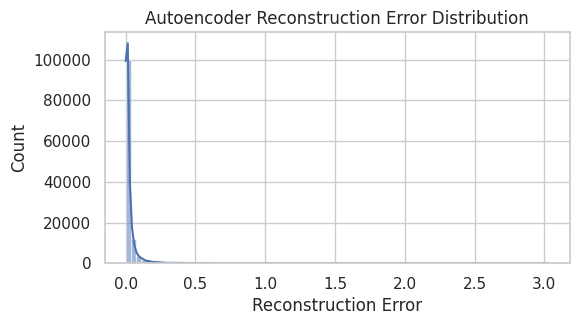

صدک 95 = 0.0989, تعداد ناهنجارهای تشخیص داده شده: 6001


,body,clean_body,ae_score
0,خیلی خیلی خیلی ارزانتر از بازار حتما از دیجی ک...,خیلی خیلی خیلی ارزانتر از بازار حتما از دیجی ک...,0.605732
1,برای پوست های خشک عالی هست و کیفیتش خیلی خوبه ...,برای پوست های خشک عالی هست و کیفیتش خیلی خوبه ...,0.213930
2,من اینو خریدم و سخت افزار مورد نیازم حتی بهتر ...,من اینو خریدم و سخت افزار مورد نیازم حتی بهتر ...,0.104841
3,به پوست سبزه میاد، خیلی هم پوسته نمیشه ولی برا...,به پوست سبزه میاد خیلی هم پوسته نمیشه ولی برای...,0.108786
4,حتما حتما پیشنهاد میکنم بخونیدش خصوصا کسانی که...,حتما حتما پیشنهاد می کنم بخونیدش خصوصا کسانی ک...,0.140404
5,جنس خیلی خوب و تنخور راحت داشت.,جنس خیلی خوب و تنخور راحت داشت,0.155616
6,ظاهر فوفق العاده جذابی داره. کیفیت چرمش عالیه....,ظاهر فوفق العاده جذابی داره کیفیت چرمش عالیه ا...,0.111449
7,گوشه پنل پاره شده بود و دو سر عرض پنل هم خیلی ...,گوشه پنل پاره شده بود و دو سر عرض پنل هم خیلی ...,0.100564


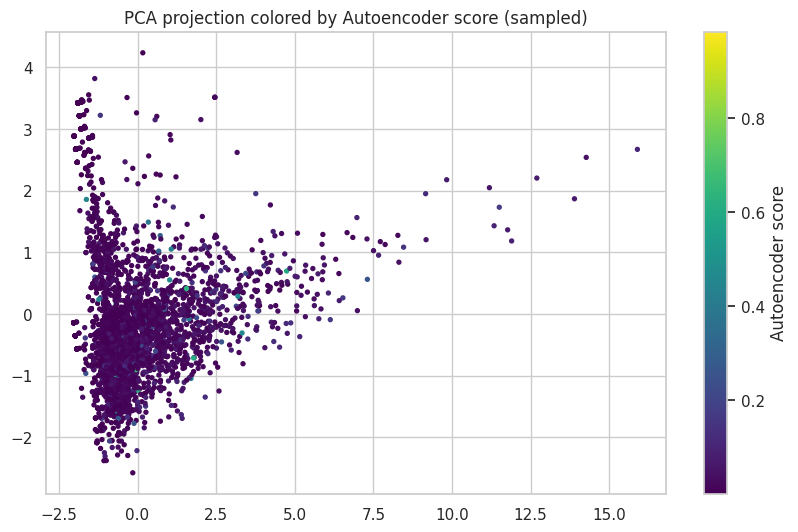

In [20]:
# =========================
# سلول 9: اجرای Autoencoder
# =========================
input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

X_pred = autoencoder.predict(X_scaled)
recon_error = np.mean(np.square(X_scaled - X_pred), axis=1)
df_out["ae_score"] = recon_error

# نمایش histogram و top anomalies
plt.figure(figsize=(6,3))
sns.histplot(df_out["ae_score"], bins=80, kde=True)
plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.show()

threshold = np.percentile(recon_error, 95)
top_idx = np.where(recon_error >= threshold)[0]
print(f"صدک 95 = {threshold:.4f}, تعداد ناهنجارهای تشخیص داده شده: {len(top_idx)}")

def show_top_texts_ae(top_idx, df=df_out, topk=8):
    display(df.iloc[top_idx][:topk][['body','clean_body']].assign(ae_score=recon_error[top_idx][:topk]).reset_index(drop=True))

show_top_texts_ae(top_idx, topk=8)

# PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
df_vis = pd.DataFrame({"pca1": X_pca[:,0], "pca2": X_pca[:,1], "ae_score": df_out["ae_score"]})
sample_vis = df_vis.sample(n=min(3000, len(df_vis)), random_state=RANDOM_SEED)

plt.figure(figsize=(10,6))
plt.scatter(sample_vis["pca1"], sample_vis["pca2"], c=sample_vis["ae_score"], s=8, cmap="viridis")
plt.colorbar(label="Autoencoder score")
plt.title("PCA projection colored by Autoencoder score (sampled)")
plt.show()


In [21]:
# ============================
# نمونه‌نمایی نظرات فیک + تفسیر انسانی + ذخیره خروجی
# ============================

import os

# تعریف فولدر خروجی
OUTPUT_DIR = "/content/drive/MyDrive/digikala_project/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# اگر threshold_percentile قبلاً تعریف نشده بود
try:
    threshold_percentile
except NameError:
    threshold_percentile = 95

# ستون‌های مدل‌ها (در صورتی که اجرا نشده باشند، از آن‌ها صرف نظر شود)
name_for_col = {
    'Isolation': 'iso_score',
    'LOF': 'lof_score',
    'KNN': 'knn_dist',
    'Ensemble': 'ensemble_score',
    'OneClassSVM': 'ocsvm_score',
    'Autoencoder': 'ae_score'
}

# انتخاب مدل‌های موجود
methods = [name for name, col in name_for_col.items() if col in df_out.columns]
method_scores = {name: df_out[name_for_col[name]].values for name in methods}

# ساخت برچسب ناهنجاری برای هر مدل
for name in methods:
    col = name_for_col[name]
    thr = np.nanpercentile(df_out[col].values, threshold_percentile)
    df_out[f'threshold_{name}'] = thr
    df_out[f'is_outlier_{name}'] = (df_out[col].values >= thr).astype(int)

# اجماع: حداقل نصف مدل‌ها رأی به ناهنجاری بدهند
vote_cols = [f'is_outlier_{m}' for m in methods]
df_out['votes'] = df_out[vote_cols].sum(axis=1)
min_votes = int(np.ceil(len(vote_cols) / 2))
df_out['is_outlier_consensus'] = (df_out['votes'] >= min_votes).astype(int)

# تابع توضیح ساده برای هر ردیف
def _explain_row(row):
    reasons = []
    if 'word_count' in row and (row['word_count'] < 3 or row['word_count'] > 80):
        reasons.append(f"طول متن غیرمعمول ({row['word_count']} کلمه)")
    if 'unique_word_ratio' in row and (row['unique_word_ratio'] < 0.30 or row['unique_word_ratio'] > 0.95):
        reasons.append(f"نسبت واژه‌های یکتا نامعمول ({row['unique_word_ratio']:.2f})")
    if 'emoji_count' in row and row['emoji_count'] > 2:
        reasons.append(f"تعداد ایموجی بالا ({row['emoji_count']})")
    if 'rate' in row and (row['rate'] <= 1 or row['rate'] >= 5):
        reasons.append(f"امتیاز افراطی ({row['rate']})")
    if 'likes' in row and 'dislikes' in row and (row['likes'] + row['dislikes']) > 0:
        like_ratio = row['likes'] / (row['likes'] + row['dislikes'] + 1e-9)
        if like_ratio > 0.95 and (row['likes'] + row['dislikes']) >= 5:
            reasons.append("الگوی تعامل نامتوازن (لایک خیلی بالا نسبت به دیسلایک)")

    voted = [m for m in methods if row.get(f'is_outlier_{m}', 0) == 1]
    if voted:
        reasons.append("تأیید چند مدل: " + "، ".join(voted))
    return "؛ ".join(reasons) if reasons else "نمره ناهنجاری بالا"

# ستون‌های قابل نمایش
base_cols = ['body', 'clean_body', 'word_count', 'unique_word_ratio', 'emoji_count', 'rate', 'likes', 'dislikes', 'votes']
score_cols_present = [name_for_col[m] for m in methods if name_for_col[m] in df_out.columns]
present_cols = [c for c in base_cols if c in df_out.columns] + score_cols_present

# دیتافریم اجماع ناهنجار
consensus_df = df_out[df_out['is_outlier_consensus'] == 1].copy()
if len(consensus_df) == 0:
    print("هیچ نظر مشکوکی بر اساس اجماع مدل‌ها یافت نشد. آستانه را تغییر دهید یا مدل‌ها را بازآموزی کنید.")
else:
    consensus_df['explain'] = consensus_df.apply(_explain_row, axis=1)

    # گزارش خلاصه برای مخاطب عام
    total_n = len(df_out)
    fake_n = int(consensus_df.shape[0])
    fake_ratio = 100.0 * fake_n / max(1, total_n)
    print(f"📝 به زبان ساده: از بین {total_n:,} نظر، حدود {fake_n:,} نظر (≈ {fake_ratio:.2f}٪) بر اساس اجماع "
          f"{min_votes}/{len(vote_cols)} مدل، مشکوک به فیک بودن هستند.")

    # نمایش تاپ K بر اساس نمره تجمیعی (اگر بود) یا تعداد رأی
    K = 8
    sort_by = 'ensemble_score' if 'ensemble_score' in consensus_df.columns else 'votes'
    print(f"\n🔎 {min(K, len(consensus_df))} نمونه از نظرات فیک (مرتب‌شده بر اساس {'ensemble_score' if sort_by=='ensemble_score' else 'تعداد رأی'}):")
    display(consensus_df.sort_values(sort_by, ascending=False).head(K)[present_cols + ['explain']])

    # نمایش نمونه‌های تصادفی
    R = min(5, len(consensus_df))
    if R > 0:
        print("\n🎯 نمونه‌های تصادفی از نظرات فیک (برای پرهیز از bias):")
        display(consensus_df.sample(R, random_state=RANDOM_SEED)[present_cols + ['explain']])

    # نمونه‌های تشخیص‌داده‌شده توسط هر مدل
    for name in methods:
        flag_col = f'is_outlier_{name}'
        if flag_col in df_out.columns and df_out[flag_col].sum() > 0:
            print(f"\n🧪 نمونه‌هایی که مدل {name} به تنهایی ناهنجار تشخیص داده است:")
            sort_col = name_for_col.get(name, score_cols_present[0] if score_cols_present else None)
            tmp = df_out[df_out[flag_col] == 1].copy()
            if sort_col in tmp.columns:
                tmp = tmp.sort_values(sort_col, ascending=False)
            tmp['explain'] = tmp.apply(_explain_row, axis=1)
            display(tmp.head(5)[present_cols + ['explain']])

# ============================
# ذخیره‌سازی خروجی‌ها برای گیت / داشبورد
# ============================
df_out.to_csv(os.path.join(OUTPUT_DIR, "df_out_with_scores.csv"), index=False)
consensus_df.to_csv(os.path.join(OUTPUT_DIR, "consensus_outliers.csv"), index=False)

print(f"\n✅ خروجی‌ها در مسیر {OUTPUT_DIR} ذخیره شدند.")


📝 به زبان ساده: از بین 120,000 نظر، حدود 3,736 نظر (≈ 3.11٪) بر اساس اجماع 3/6 مدل، مشکوک به فیک بودن هستند.

🔎 8 نمونه از نظرات فیک (مرتب‌شده بر اساس ensemble_score):


,body,clean_body,word_count,unique_word_ratio,emoji_count,rate,likes,dislikes,votes,iso_score,lof_score,knn_dist,ensemble_score,ocsvm_score,ae_score,explain
83211,فوق العاده عالی بود,فوق العاده عالی بود,4,1.0000,0,5.0,0,0,4,-0.002917,3.297179e+10,4.766614,0.680166,-0.579259,0.046238,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
58992,واقعا فوق العاده بود,واقعا فوق العاده بود,4,1.0000,0,5.0,0,0,5,-0.013302,3.438539e+10,4.943314,0.669220,-0.329163,0.044335,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
38952,کتاب خوبیه قیمتش خیلی خوب بود,کتاب خوبیه قیمتش خیلی خوب بود,6,1.0000,0,0.0,1,0,5,-0.020936,3.161488e+10,6.129333,0.642797,-4.526005,0.184168,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
77578,این محصول اولین اینکه پلمپ نیست\r\nبعدم اینکه ...,این محصول اولین اینکه پلمپ نیست بعدم اینکه بزن...,80,0.7875,0,0.0,184,1,4,-0.028062,-5.161121e+09,30.136125,0.601671,7.533026,0.901852,امتیاز افراطی (0.0)؛ الگوی تعامل نامتوازن (لای...
115101,بسیار خوشبو و با کیفیت,بسیار خوشبو و با کیفیت,5,1.0000,0,5.0,0,0,5,-0.024947,2.855471e+10,5.195227,0.599030,0.000421,0.061396,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
94275,این کتاب عالیه توسعه میکنم,این کتاب عالیه توسعه می کنم,6,1.0000,0,5.0,0,0,4,-0.019560,2.630809e+10,5.244868,0.594332,-3.438833,0.012073,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
350,خوبه \nراضیییییییییییییییییییییییییی...,خوبه راضی راضی ام,4,0.7500,0,4.0,0,0,3,-0.025676,2.827089e+10,4.179002,0.583863,-1.496539,0.048623,تأیید چند مدل: Isolation، LOF، Ensemble
34475,خوب بود. آثار نویسندگان روس فوق العاده س,خوب بود آثار نویسندگان روس فوق العاده س,8,1.0000,0,5.0,2,0,3,-0.003664,2.249063e+10,3.456469,0.581249,-2.409092,0.051745,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...



🎯 نمونه‌های تصادفی از نظرات فیک (برای پرهیز از bias):


,body,clean_body,word_count,unique_word_ratio,emoji_count,rate,likes,dislikes,votes,iso_score,lof_score,knn_dist,ensemble_score,ocsvm_score,ae_score,explain
103619,خیلی خوبه بسته بندی عالی,خیلی خوبه بسته بندی عالی,5,1.000000,0,4.0,1,0,3,-0.005560,-5.161121e+09,3.169924,0.355520,-1.828518,0.291023,نسبت واژه‌های یکتا نامعمول (1.00)؛ تأیید چند م...
108218,فوق العاده با کیفیت بود پیشنهاد میکنم,فوق العاده با کیفیت بود پیشنهاد می کنم,8,1.000000,0,5.0,0,0,3,-0.025538,-5.161121e+09,4.180631,0.320426,-2.744116,0.321939,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
49094,برای آشنایی با عقاید اگزیستانسیالیستی,برای آشنایی با عقاید اگزیستانسیالیستی,5,1.000000,0,0.0,1,0,4,-0.003622,-5.161121e+09,5.865423,0.389823,1.403982,0.054271,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...
108548,با سلام\r\n\r\nمن برای پسرم خریدم از جلد اول ت...,با سلام من برای پسرم خریدم از جلد اول تا جلد د...,58,0.741379,0,4.0,4,2,4,-0.025032,-5.161121e+09,5.284113,0.333803,-9.348977,0.167029,تأیید چند مدل: Isolation، KNN، Ensemble، Autoe...
21424,بسته بندی و کیفیت خوب بود ممنون,بسته بندی و کیفیت خوب بود ممنون,7,1.000000,0,4.0,0,0,3,-0.009488,-5.161121e+09,5.363339,0.370681,-2.146512,0.035584,نسبت واژه‌های یکتا نامعمول (1.00)؛ تأیید چند م...



🧪 نمونه‌هایی که مدل Isolation به تنهایی ناهنجار تشخیص داده است:


...


🧪 نمونه‌هایی که مدل OneClassSVM به تنهایی ناهنجار تشخیص داده است:


,body,clean_body,word_count,unique_word_ratio,emoji_count,rate,likes,dislikes,votes,iso_score,lof_score,knn_dist,ensemble_score,ocsvm_score,ae_score,explain
77578,این محصول اولین اینکه پلمپ نیست\r\nبعدم اینکه ...,این محصول اولین اینکه پلمپ نیست بعدم اینکه بزن...,80,0.787500,0,0.0,184,1,4,-0.028062,-5.161121e+09,30.136125,0.601671,7.533026,0.901852,امتیاز افراطی (0.0)؛ الگوی تعامل نامتوازن (لای...
2775,با سلام اول از همه چند تا نکته میگم امیدوارم ت...,با سلام اول از همه چند تا نکته میگم امیدوارم ت...,706,0.453258,0,5.0,14,0,4,-0.031390,-5.161121e+09,23.915644,0.525159,7.532765,2.518463,طول متن غیرمعمول (706 کلمه)؛ امتیاز افراطی (5....
12493,خیللییییییی عاااالییییه \r\nتیکه داستان های شه...,خیللیی عالیه تیکه داستان های شهید حاج قاسم سلی...,43,0.860465,0,5.0,13,46,5,-0.023882,-5.161121e+09,19.701493,0.495937,7.517615,0.473399,امتیاز افراطی (5.0)؛ تأیید چند مدل: Isolation،...
62903,واقعا خیلی خوبه من روی لاک بنفش که زدم خیلی قش...,واقعا خیلی خوبه من روی لاک بنفش که زدم خیلی قش...,12,0.916667,0,5.0,137,7,4,-0.032991,-5.161121e+09,19.946122,0.477546,7.503601,0.666469,امتیاز افراطی (5.0)؛ الگوی تعامل نامتوازن (لای...
59709,دیجی کالا این رنگ رو مشکی میبینه,دیجی کالا این رنگ رو مشکی میبینه,7,1.000000,0,3.0,93,0,4,-0.079626,-5.161121e+09,17.653080,0.344169,7.503189,0.300436,نسبت واژه‌های یکتا نامعمول (1.00)؛ الگوی تعامل...



🧪 نمونه‌هایی که مدل Autoencoder به تنهایی ناهنجار تشخیص داده است:


,body,clean_body,word_count,unique_word_ratio,emoji_count,rate,likes,dislikes,votes,iso_score,lof_score,knn_dist,ensemble_score,ocsvm_score,ae_score,explain
27441,کتاب خوبیه👌🏻👌🏻,کتاب خوبیه,2,1.000000,1,5.0,0,0,5,-0.010012,-5.161121e+09,7.559424,0.393760,4.164178,3.028484,طول متن غیرمعمول (2 کلمه)؛ نسبت واژه‌های یکتا ...
31403,👌کتاب خوبیه,کتاب خوبیه,2,1.000000,1,4.0,0,0,5,-0.014491,-5.161121e+09,7.577410,0.383584,4.137451,3.021795,طول متن غیرمعمول (2 کلمه)؛ نسبت واژه‌های یکتا ...
25509,راضیم 👌🏼 عالی 👍🏼,راضیم عالی,2,1.000000,2,5.0,0,0,4,-0.038299,-5.161121e+09,13.462521,0.393536,6.856999,2.702189,طول متن غیرمعمول (2 کلمه)؛ نسبت واژه‌های یکتا ...
2775,با سلام اول از همه چند تا نکته میگم امیدوارم ت...,با سلام اول از همه چند تا نکته میگم امیدوارم ت...,706,0.453258,0,5.0,14,0,4,-0.031390,-5.161121e+09,23.915644,0.525159,7.532765,2.518463,طول متن غیرمعمول (706 کلمه)؛ امتیاز افراطی (5....
93209,دیجی کالا واقعا فوق العاده هست👏👏👏,دیجی کالا واقعا فوق العاده هست,6,1.000000,1,0.0,0,0,4,-0.030912,-5.161121e+09,12.882018,0.404225,6.354995,2.272539,نسبت واژه‌های یکتا نامعمول (1.00)؛ امتیاز افرا...



✅ خروجی‌ها در مسیر /content/drive/MyDrive/digikala_project/output ذخیره شدند.
